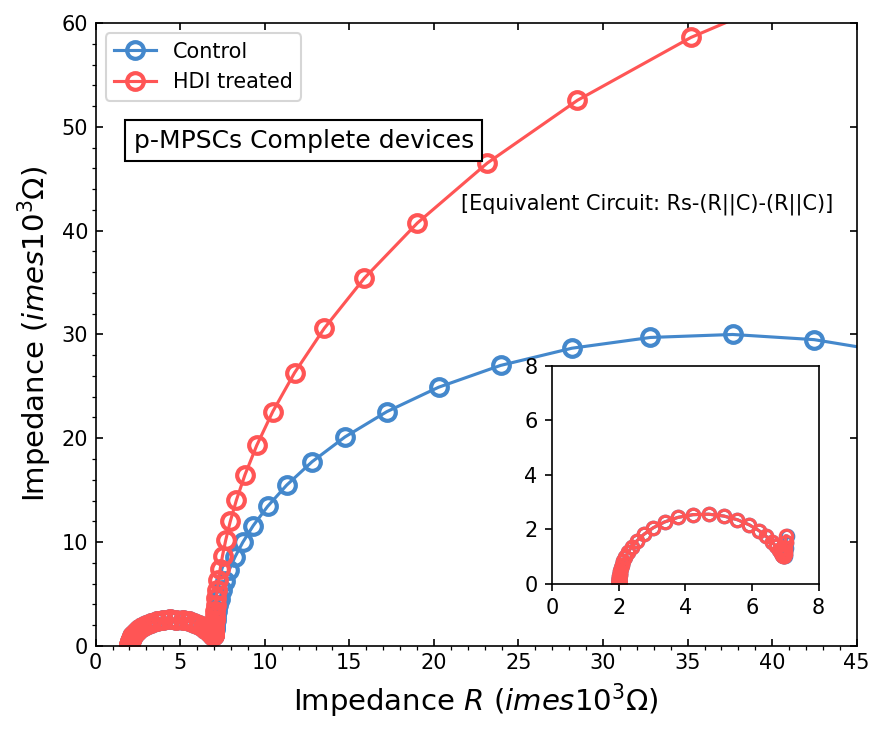

In [1]:
import matplotlib.pyplot as plt
import numpy as np


# --- Data Simulation ---
# Generate full Nyquist plot with Warburg (Line at 45 deg) or just huge second arc
def impedance_curve(Rs, R1, C1, R2, C2, freq):
    w = 2 * np.pi * freq
    Z1 = R1 / (1 + 1j * w * R1 * C1)
    Z2 = R2 / (1 + 1j * w * R2 * C2)
    Z = Rs + Z1 + Z2
    return Z.real, -Z.imag

freq = np.logspace(6, -1, 100)

# Control (Blue) - Smaller R2
z_real_ctrl, z_imag_ctrl = impedance_curve(2, 5, 1e-5, 60, 1e-3, freq) # Adjusted for shape

# HDI (Red) - Larger R2 (Huge)
z_real_hdi, z_imag_hdi = impedance_curve(2, 5, 1e-5, 150, 1e-3, freq)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Plots
ax.plot(z_real_ctrl, z_imag_ctrl, 'o-', color='#4488CC', mfc='none', markersize=8, mew=2, label='Control')
ax.plot(z_real_hdi, z_imag_hdi, 'o-', color='#FF5555', mfc='none', markersize=8, mew=2, label='HDI treated')

# Legend
ax.legend(frameon=True, loc='upper left', fontsize=10)
ax.text(0.05, 0.8, 'p-MPSCs Complete devices', transform=ax.transAxes, fontsize=12, bbox=dict(facecolor='white', edgecolor='black'))

# Schematic
ax_sch = ax.inset_axes([0.5, 0.6, 0.45, 0.2])
ax_sch.axis('off')
# Simple drawing
ax_sch.text(0.5, 0.5, '[Equivalent Circuit: Rs-(R||C)-(R||C)]', ha='center')

# Zoom Inset
ax_ins = ax.inset_axes([0.6, 0.1, 0.35, 0.35])
# Plot High Freq part
freq_zoom = np.logspace(6, 2, 50)
zr_c_z, zi_c_z = impedance_curve(2, 5, 1e-5, 60, 1e-3, freq_zoom)
zr_h_z, zi_h_z = impedance_curve(2, 5, 1e-5, 150, 1e-3, freq_zoom)

ax_ins.plot(zr_c_z, zi_c_z, 'o-', color='#4488CC', mfc='none', markersize=6, mew=1.5)
ax_ins.plot(zr_h_z, zi_h_z, 'o-', color='#FF5555', mfc='none', markersize=6, mew=1.5)
ax_ins.set_xlim(0, 8)
ax_ins.set_ylim(0, 8)

# Styling
ax.set_xlabel(r'Impedance $R$ ($	imes 10^3 \Omega$)', fontsize=14)
ax.set_ylabel(r'Impedance ($	imes 10^3 \Omega$)', fontsize=14) # Sic
ax.set_xlim(0, 45)
ax.set_ylim(0, 60)

# Ticks
ax.minorticks_on()
ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.show()
